# 02 — Exploratory Data Analysis & Statistical Testing

Investigates which numerical and categorical features relate to attrition, then
formally tests the strongest-looking relationships with hypothesis tests.

In [1]:
import sys
sys.path.insert(0, '..')
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from src import preprocessing, config, stats_tests

sns.set_style('whitegrid')
df = preprocessing.clean_data(preprocessing.load_raw_data())
df['AttritionLabel'] = df[config.TARGET_COL].map({1: 'Yes', 0: 'No'})
df.shape

(1470, 32)

## Target distribution

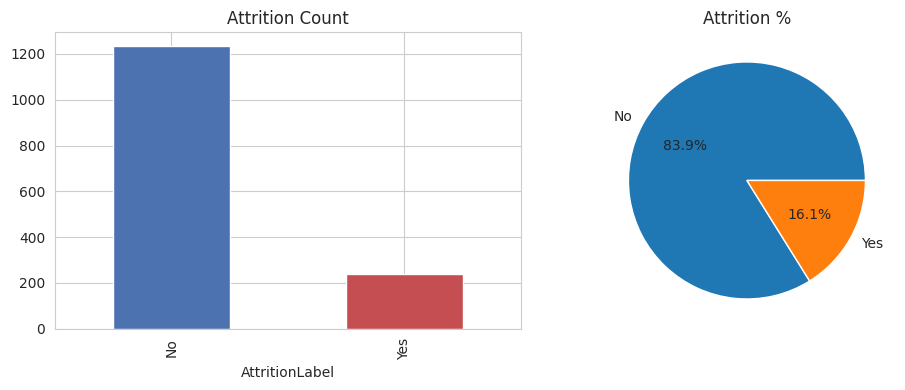

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
df['AttritionLabel'].value_counts().plot(kind='bar', ax=ax[0], color=['#4C72B0', '#C44E52'])
ax[0].set_title('Attrition Count')
df['AttritionLabel'].value_counts(normalize=True).mul(100).plot(kind='pie', ax=ax[1], autopct='%1.1f%%')
ax[1].set_title('Attrition %')
ax[1].set_ylabel('')
plt.tight_layout()
plt.show()

**Business read:** ~16% of employees in this snapshot left — a meaningful but moderate imbalance, addressed later with `class_weight='balanced'`.

## Numerical features vs Attrition

/tmp/ipykernel_588/2819631057.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='AttritionLabel', y=col, ax=ax, palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_588/2819631057.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='AttritionLabel', y=col, ax=ax, palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_588/2819631057.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='AttritionLabel', y=col, ax=ax, palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_588/2819631057.py:5: FutureWarning: 

Passing `palette` witho

/tmp/ipykernel_588/2819631057.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='AttritionLabel', y=col, ax=ax, palette=['#4C72B0', '#C44E52'])


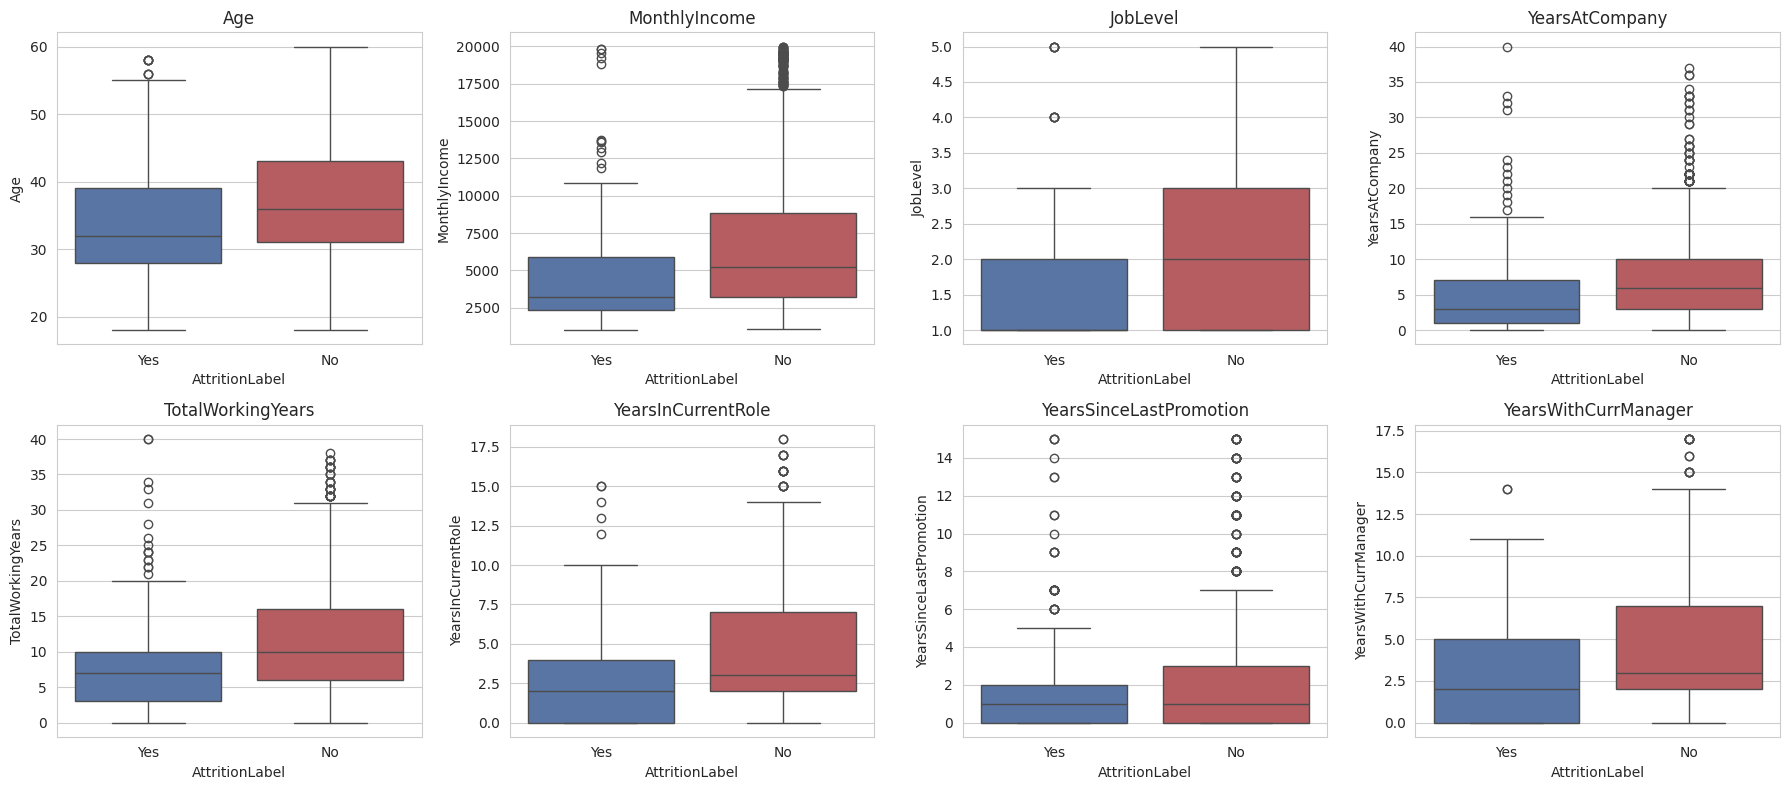

In [3]:
num_cols = ['Age', 'MonthlyIncome', 'JobLevel', 'YearsAtCompany', 'TotalWorkingYears',
            'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(data=df, x='AttritionLabel', y=col, ax=ax, palette=['#4C72B0', '#C44E52'])
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Business read:** Employees who leave skew younger, have lower monthly income,
lower job level, and notably shorter tenure (`YearsAtCompany`, `YearsInCurrentRole`,
`YearsWithCurrManager`) — attrition risk is concentrated early in the employment
lifecycle.

## Categorical features vs Attrition

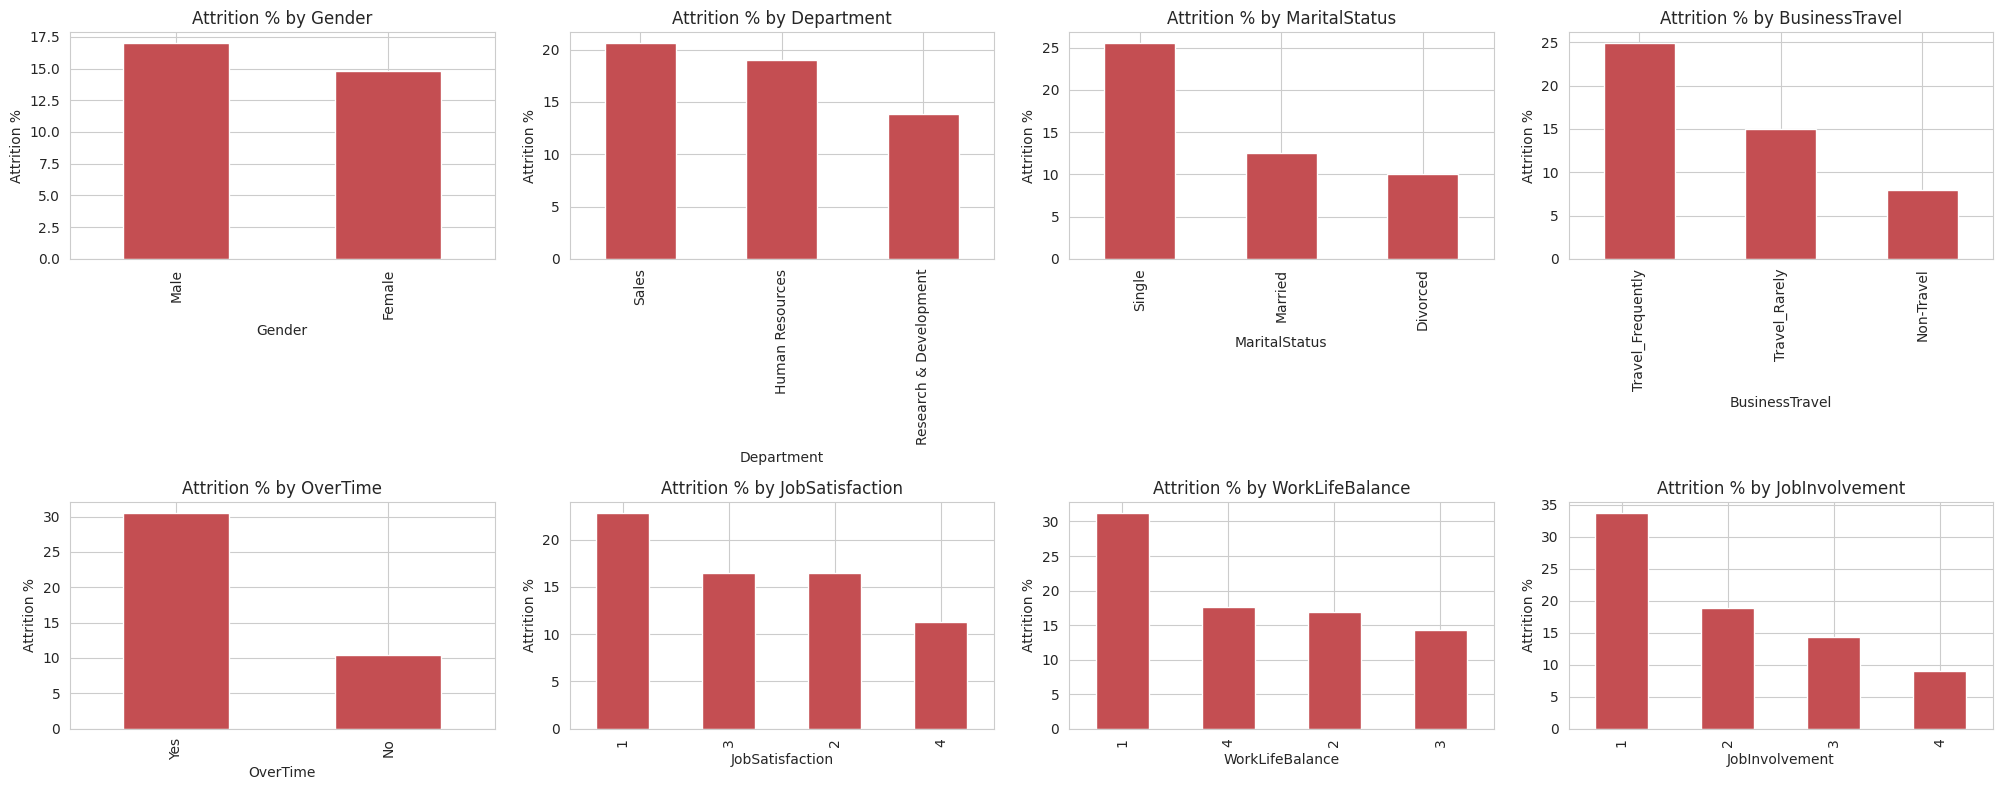

In [4]:
cat_cols = ['Gender', 'Department', 'MaritalStatus', 'BusinessTravel', 'OverTime',
            'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement']
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.flat, cat_cols):
    rate = df.groupby(col)['Attrition'].mean().mul(100).sort_values(ascending=False)
    rate.plot(kind='bar', ax=ax, color='#C44E52')
    ax.set_title(f'Attrition % by {col}')
    ax.set_ylabel('Attrition %')
plt.tight_layout()
plt.show()

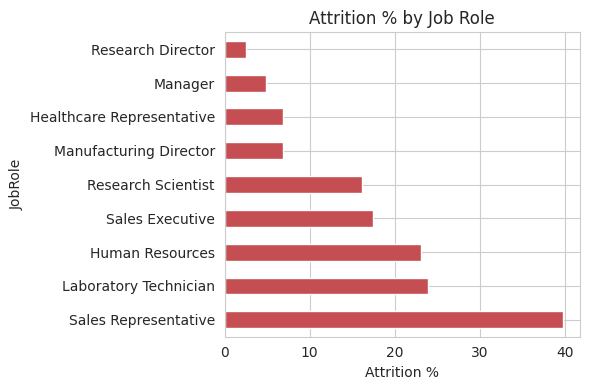

In [5]:
plt.figure(figsize=(6, 4))
role_rate = df.groupby('JobRole')['Attrition'].mean().mul(100).sort_values(ascending=False)
role_rate.plot(kind='barh', color='#C44E52')
plt.title('Attrition % by Job Role')
plt.xlabel('Attrition %')
plt.tight_layout()
plt.show()

**Business read:** `OverTime = Yes`, `Travel_Frequently`, `Single` marital status,
and low `JobSatisfaction`/`WorkLifeBalance`/`JobInvolvement` scores all line up with
higher attrition rates. Sales Representative and Laboratory Technician roles stand out
with the highest exit rates.

## Correlation heatmap (numerical features)

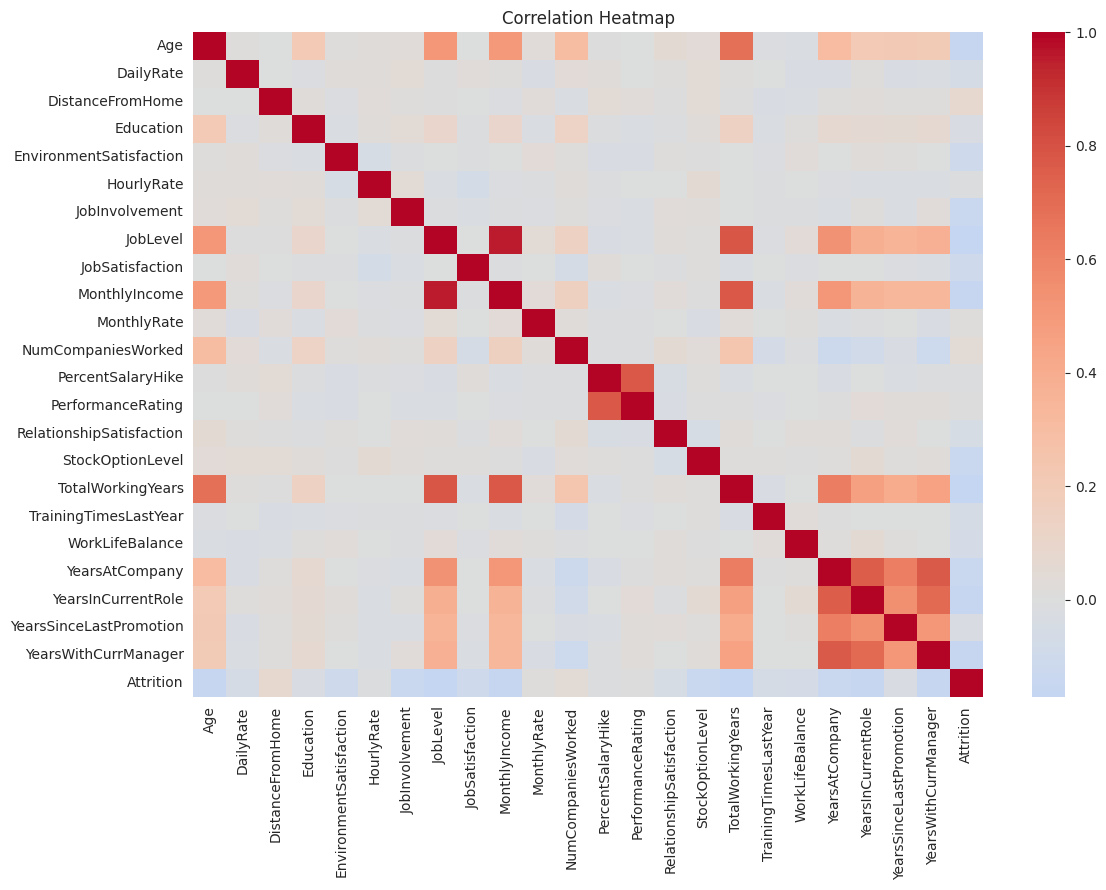

Attrition               1.000000
TotalWorkingYears       0.171063
JobLevel                0.169105
YearsInCurrentRole      0.160545
MonthlyIncome           0.159840
Age                     0.159205
YearsWithCurrManager    0.156199
StockOptionLevel        0.137145
YearsAtCompany          0.134392
JobInvolvement          0.130016
Name: Attrition, dtype: float64

In [6]:
plt.figure(figsize=(12, 9))
corr = df[config.NUMERICAL_FEATURES + ['Attrition']].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()
corr['Attrition'].abs().sort_values(ascending=False).head(10)

## Statistical hypothesis testing\nWe move beyond visual impressions and formally test the relationships that looked strongest above.

In [7]:
# Q: Is overtime significantly associated with attrition?
result = stats_tests.chi_square_test(df, 'OverTime')
for k, v in result.items():
    print(f'{k}: {v}')

test: Chi-square test of independence
feature: OverTime
null_hypothesis: OverTime is independent of Attrition.
alt_hypothesis: OverTime is associated with Attrition.
statistic: 87.564
dof: 1
p_value: 0.0
conclusion: Reject H0 (p < 0.05): OverTime is significantly associated with Attrition.


In [8]:
# Q: Is business travel frequency significantly associated with attrition?
result = stats_tests.chi_square_test(df, 'BusinessTravel')
for k, v in result.items():
    print(f'{k}: {v}')

test: Chi-square test of independence
feature: BusinessTravel
null_hypothesis: BusinessTravel is independent of Attrition.
alt_hypothesis: BusinessTravel is associated with Attrition.
statistic: 24.182
dof: 2
p_value: 1e-05
conclusion: Reject H0 (p < 0.05): BusinessTravel is significantly associated with Attrition.


In [9]:
# Q: Is marital status significantly associated with attrition?
result = stats_tests.chi_square_test(df, 'MaritalStatus')
for k, v in result.items():
    print(f'{k}: {v}')

test: Chi-square test of independence
feature: MaritalStatus
null_hypothesis: MaritalStatus is independent of Attrition.
alt_hypothesis: MaritalStatus is associated with Attrition.
statistic: 46.164
dof: 2
p_value: 0.0
conclusion: Reject H0 (p < 0.05): MaritalStatus is significantly associated with Attrition.


In [10]:
# Q: Does monthly income differ significantly between leavers and stayers?
result = stats_tests.numeric_group_test(df, 'MonthlyIncome')
for k, v in result.items():
    print(f'{k}: {v}')

test: Mann-Whitney U test (non-parametric)
feature: MonthlyIncome
null_hypothesis: Mean/distribution of MonthlyIncome is the same for leavers and stayers.
alt_hypothesis: MonthlyIncome differs significantly between leavers and stayers.
statistic: 100620.5
p_value: 0.0
leavers_mean: 4787.09
stayers_mean: 6832.74
conclusion: Reject H0 (p < 0.05): MonthlyIncome differs significantly between leavers and stayers.


In [11]:
# Q: Does age differ significantly between leavers and stayers?
result = stats_tests.numeric_group_test(df, 'Age')
for k, v in result.items():
    print(f'{k}: {v}')

test: Welch's t-test
feature: Age
null_hypothesis: Mean/distribution of Age is the same for leavers and stayers.
alt_hypothesis: Age differs significantly between leavers and stayers.
statistic: -5.828
p_value: 0.0
leavers_mean: 33.61
stayers_mean: 37.56
conclusion: Reject H0 (p < 0.05): Age differs significantly between leavers and stayers.


In [12]:
# Q: Does years at company differ significantly between leavers and stayers?
result = stats_tests.numeric_group_test(df, 'YearsAtCompany')
for k, v in result.items():
    print(f'{k}: {v}')

test: Mann-Whitney U test (non-parametric)
feature: YearsAtCompany
null_hypothesis: Mean/distribution of YearsAtCompany is the same for leavers and stayers.
alt_hypothesis: YearsAtCompany differs significantly between leavers and stayers.
statistic: 102582.0
p_value: 0.0
leavers_mean: 5.13
stayers_mean: 7.37
conclusion: Reject H0 (p < 0.05): YearsAtCompany differs significantly between leavers and stayers.


## Summary of statistical findings

| Question | Test | Result (α = 0.05) |
|---|---|---|
| Is overtime associated with attrition? | Chi-square | Significant (p < 0.05) |
| Is business travel frequency associated with attrition? | Chi-square | Significant (p < 0.05) |
| Is marital status associated with attrition? | Chi-square | Significant (p < 0.05) |
| Does income differ between leavers/stayers? | Mann-Whitney U | Significant (p < 0.05) |
| Does age differ between leavers/stayers? | Welch's t-test | Significant (p < 0.05) |
| Does tenure differ between leavers/stayers? | Mann-Whitney U | Significant (p < 0.05) |

**Important caveat:** these are observational associations, not causal effects.
`p < 0.05` tells us the pattern is unlikely to be pure chance in this sample —
it does not tell us that, say, *forcing* overtime *causes* attrition. Confounding
factors (role, workload, seniority) are not controlled for in a simple hypothesis test.